In [1]:
# pip install kagglehub[pandas-datasets]

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

In [3]:
# Original source: samartalwar/sleep-debt-and-screen-time-late-night-phone-habits on Kaggle.
# Analysis uses the saved CSV below; no download or overwrite is needed.


In [4]:
# load from csv, assuming the file is data/bedtime_screentime_sleep_debt.csv

df = pd.read_csv("data/bedtime_screentime_sleep_debt.csv")

In [5]:
df.describe()

,age,bedtime_phone_minutes,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score
count,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000
mean,34.355647,59.250000,55.153882,0.467765,33.222471,35.701412,40.671471,6.266209,21.735741,19.105859,2.766000,3.794671
std,11.584259,36.931991,19.850550,0.498989,51.935645,20.819390,17.444914,1.446258,3.069377,2.546459,1.695407,2.685153
min,18.000000,1.000000,10.000000,0.000000,0.000000,0.000000,6.000000,3.200000,8.100000,9.600000,0.000000,1.000000
25%,25.000000,31.000000,42.000000,0.000000,0.000000,21.000000,28.200000,5.240000,19.700000,17.400000,2.000000,1.100000
50%,32.000000,51.000000,55.000000,0.000000,0.000000,35.000000,37.600000,6.330000,21.900000,19.100000,3.000000,3.200000
75%,42.000000,79.000000,69.000000,1.000000,55.000000,50.000000,49.700000,7.350000,23.900000,20.800000,4.000000,5.600000
max,65.000000,180.000000,100.000000,1.000000,250.000000,112.000000,123.300000,9.800000,28.000000,27.000000,7.000000,10.000000


In [6]:
df.columns

Index(['user_id', 'age', 'gender', 'occupation_type', 'chronotype',
       'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct',
       'blue_light_filter_active', 'caffeine_post_5pm_mg',
       'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours',
       'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes',
       'next_day_fatigue_score', 'sleep_debt_category'],
      dtype='object')

In [7]:
df['occupation_type'].unique()

array(['Healthcare / Shift Worker', 'Student', 'Remote Tech',
       'Freelance / Creative', 'Corporate 9-to-5'], dtype=object)

In [8]:
df['primary_bedtime_app'].unique()

array(['Instagram / Reddit', 'YouTube', 'TikTok / Reels',
       'News / Reading', 'Streaming (Netflix/Hulu)', 'Messaging / Chat'],
      dtype=object)

## What Makes Doomscrolling Worse?
If someone spends a long time on their phone before bed, what other behaviors are associated with making the sleep penalty larger or smaller?

We'll start by investigating a relationship between screen time and REM Sleep

In [13]:
# Investigating the relationship between REM sleep and screen time
rem = df['rem_sleep_pct'] 
bed_minutes = df['bedtime_phone_minutes']

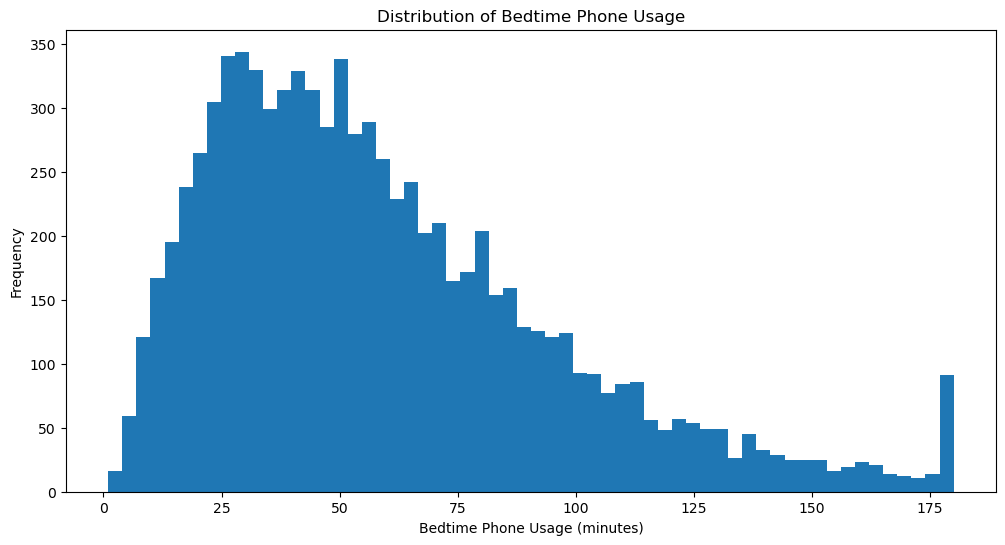

In [ ]:

# Creating a histogram for bedtime phone usage
plt.figure(figsize=(12, 6))
plt.hist(bed_minutes, bins=60)
plt.xlabel('Bedtime Phone Usage (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Bedtime Phone Usage')
plt.show()

More people tend to use up to an hour of their phone in bed.

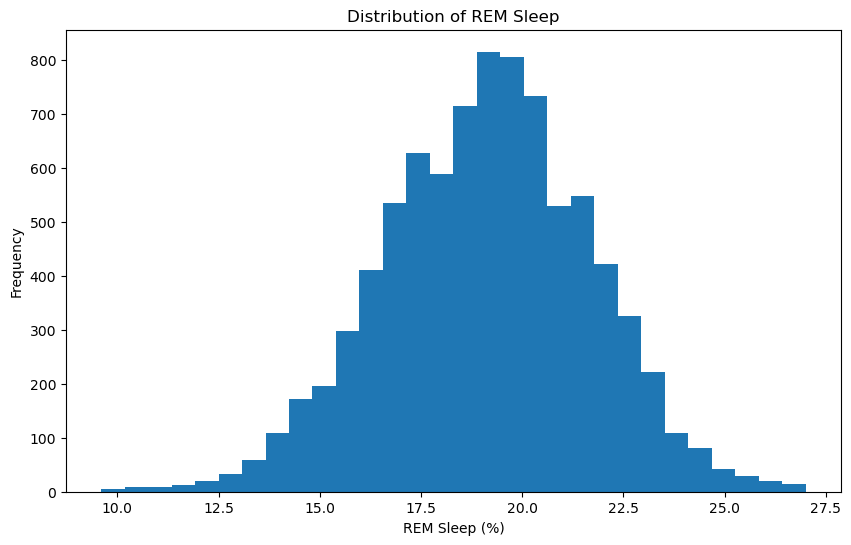

In [17]:
# Creating a histogram for REM sleep
plt.figure(figsize=(10, 6))
plt.hist(rem, bins=30)
plt.xlabel('REM Sleep (%)')
plt.ylabel('Frequency')
plt.title('Distribution of REM Sleep')
plt.show()


People tend to get around 15-22.5% REM Sleep.

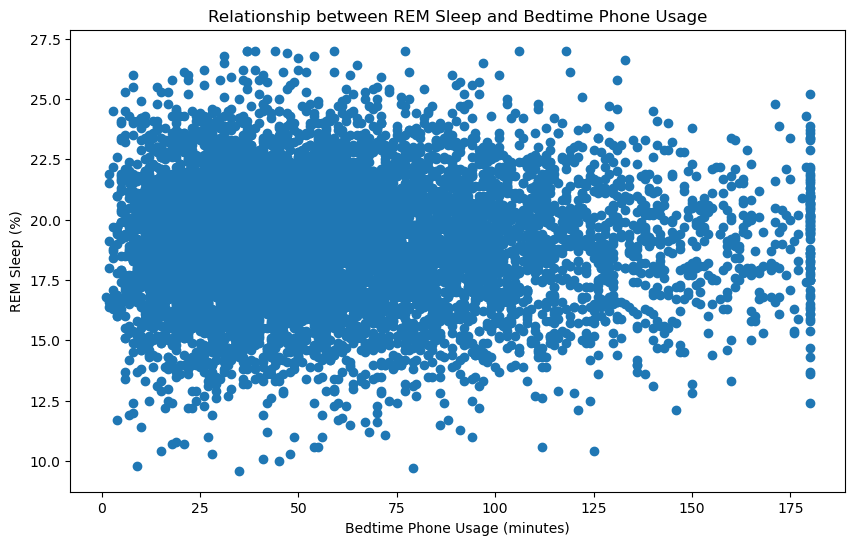

<Figure size 1000x600 with 0 Axes>

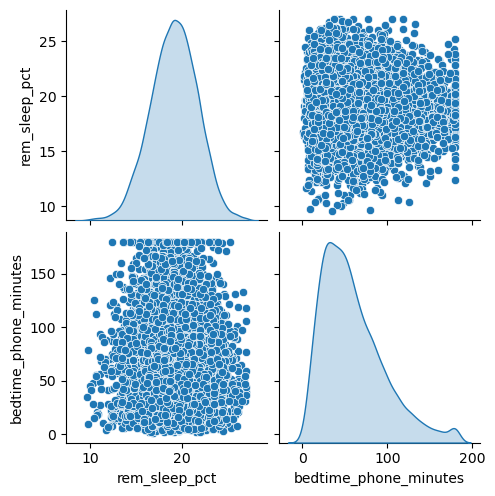

In [16]:
# Investigating relationship between REM sleep and bedtime phone usage through different types of plots
plt.figure(figsize=(10, 6))
plt.scatter(bed_minutes, rem)
plt.xlabel('Bedtime Phone Usage (minutes)')
plt.ylabel('REM Sleep (%)')
plt.title('Relationship between REM Sleep and Bedtime Phone Usage')
plt.show()

# Creating a pairplot for REM sleep and bedtime phone usage
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.pairplot(df[['rem_sleep_pct', 'bedtime_phone_minutes']], diag_kind='kde')
plt.show()

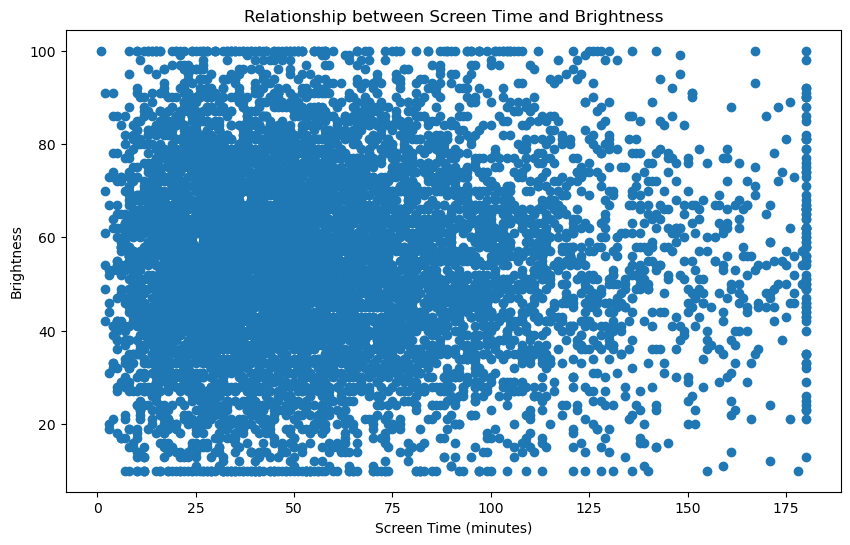

In [23]:
# Let's explore a relationship between screen time and brightness next
bed_minutes
brightness = df['screen_brightness_pct']

plt.figure(figsize=(10, 6))
plt.scatter(bed_minutes, brightness)
plt.xlabel('Screen Time (minutes)')
plt.ylabel('Brightness')
plt.title('Relationship between Screen Time and Brightness')
plt.show()

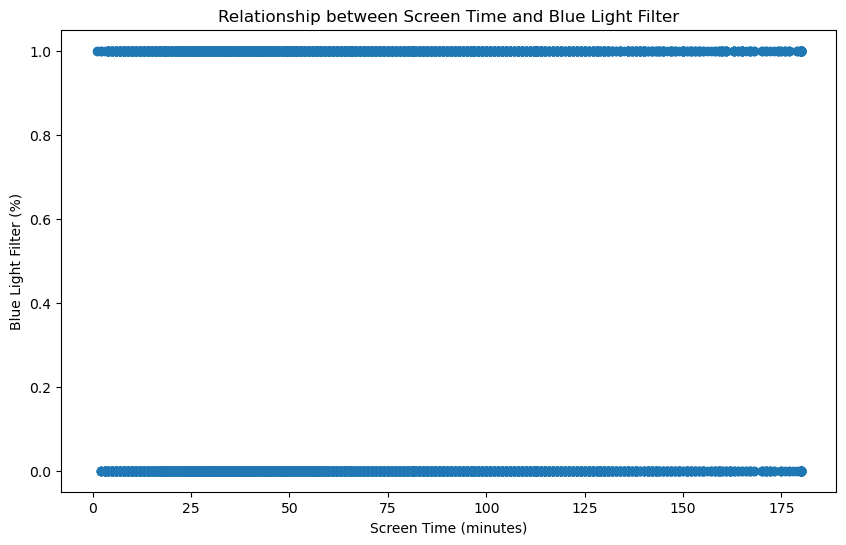

In [29]:
# Let's explore a relationship between screen time and the blue light filter next
bed_minutes
blue_light_filter = df['blue_light_filter_active']

plt.figure(figsize=(10, 6))
plt.scatter(bed_minutes, blue_light_filter)
plt.xlabel('Screen Time (minutes)')
plt.ylabel('Blue Light Filter (%)')
plt.title('Relationship between Screen Time and Blue Light Filter')
plt.show()

This doesn't explain much, so let's try something else

In [27]:
blue_light_filter.value_counts()

blue_light_filter_active
0    4524
1    3976
Name: count, dtype: int64

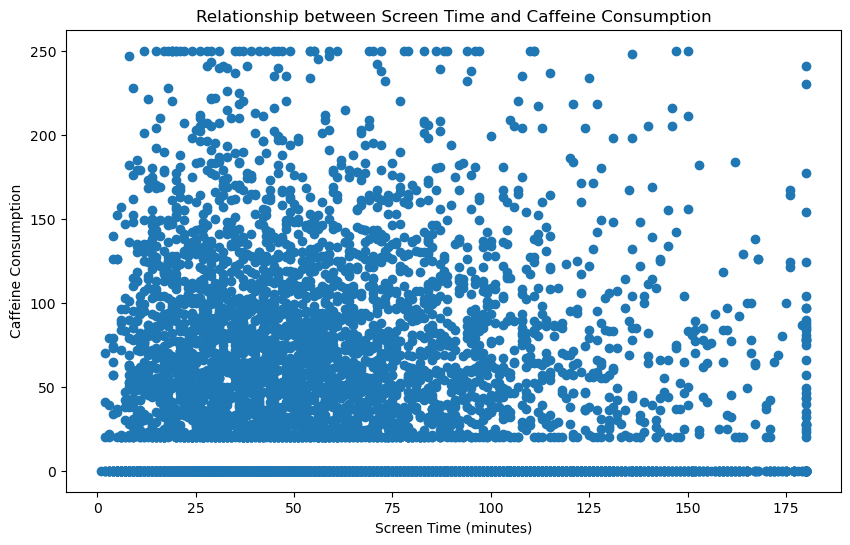

In [31]:
# Let's explore the relationship between screen time and caffeine in the evening next
bed_minutes
caffeine = df['caffeine_post_5pm_mg']

plt.figure(figsize=(10, 6))
plt.scatter(bed_minutes, caffeine)
plt.xlabel('Screen Time (minutes)')
plt.ylabel('Caffeine Consumption')
plt.title('Relationship between Screen Time and Caffeine Consumption')
plt.show()

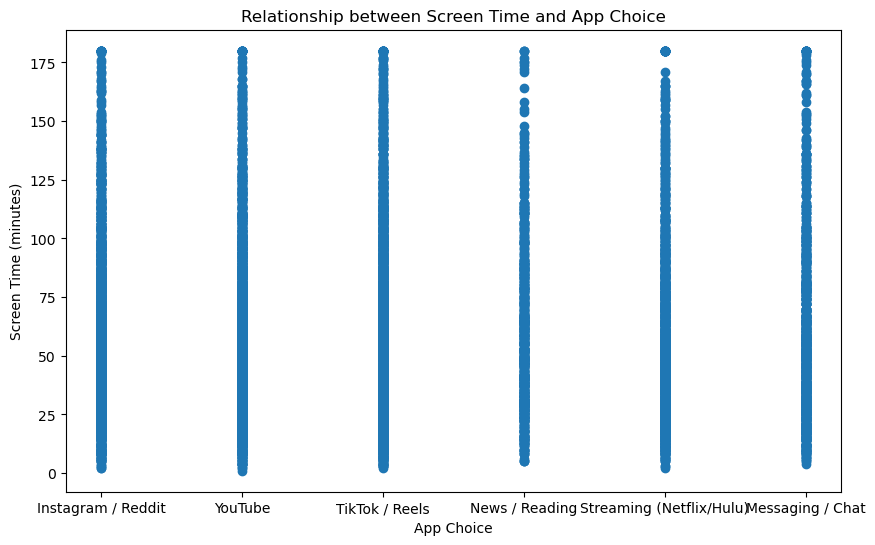

In [ ]:
# let's explore the relationship between screen time and app choice with increased shading
app = df['primary_bedtime_app']

plt.figure(figsize=(10, 6))
plt.scatter(app, bed_minutes)
plt.xlabel('App Choice')
plt.ylabel('Screen Time (minutes)')
plt.title('Relationship between Screen Time and App Choice')
plt.show()

The type of app used doesn't seem to contribute as much to 